In [20]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

X = load_iris().data                 # 붓꽃 특성 4개 (정답인 품종은 안 씀)
km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = km.fit_predict(X)           # 각 꽃이 몇 번 무리인지 (0,1,2)
print(labels[:])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [26]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = load_wine().data                        # 와인 성분 13개 (단위가 제각각)
X_s = StandardScaler().fit_transform(X)     # 같은 잣대로 맞추기 (거리 기반이라 필수)

km = KMeans(n_clusters=2, random_state=0, n_init=10)
labels = km.fit_predict(X_s)

print('무리별 개수:', np.bincount(labels))
print('실루엣 점수:', round(silhouette_score(X_s, labels), 3))

무리별 개수: [113  65]
실루엣 점수: 0.268


In [55]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 공개 미러 URL로 바로 불러오기 (Kaggle 'Mall Customers')
url = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv'
df = pd.read_csv(url)                # 고객 200명 (다운로드 불필요)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # 연소득·소비점수
X_s = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=5, random_state=0, n_init=10)
df['segment'] = km.fit_predict(X_s)                       # 고객을 5유형으로

print(df.groupby('segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

print('실루엣 점수:', round(silhouette_score(X_s, df['segment']), 3))

         Annual Income (k$)  Spending Score (1-100)
segment                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      88.2                    17.1
3                      26.3                    20.9
4                      25.7                    79.4
실루엣 점수: 0.555


In [34]:
print(type(df['segment']))

<class 'pandas.core.series.Series'>


In [40]:
X_s[:10]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002]])

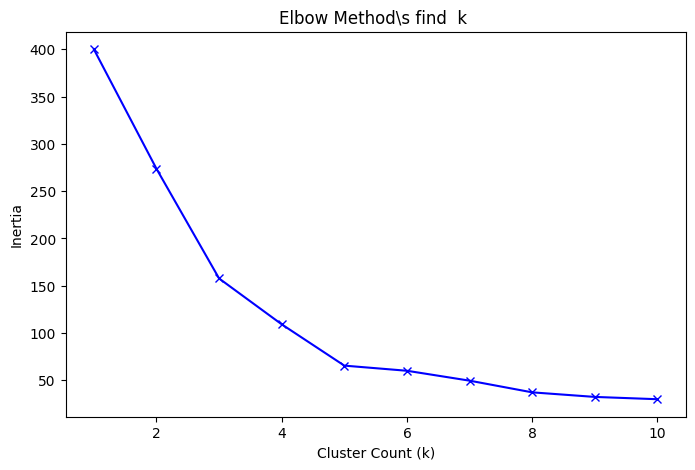

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# 적절한 k 찾기 (Elbow Method)
inertia = []    # 각 k 값에 대한 군집 내 거리 제곱합(Inertia)을 저장할 리스트
K = range(1,11) # K 범위 (1 - 10) 클러스터(군집그룹) 개수

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42) # 클러스터 개수를 k로 지정
    kmeans.fit(X_s)  # 훈련 데이터로 학습 수행
    inertia.append(kmeans.inertia_) # 각 k에 대한 Inertia(거리 제곱합) 저장

# Elbow 그래프 시각화
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method\s find  k ')
plt.show()